In [26]:
#import libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from keras.datasets import fashion_mnist
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist

In [27]:
#load the data
fashion_mnist=keras.datasets.fashion_mnist # Loading the dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [28]:
# explore the data
print(f"We have {len(X_train)} images in the training set and {len(X_test)} images in the test set.")
print(f"The size of the images is {X_train[0].shape}.")

We have 60000 images in the training set and 10000 images in the test set.
The size of the images is (28, 28).


In [29]:
import matplotlib.pyplot as plt
%matplotlib inline

print('Training data shape : ', X_train.shape, y_train.shape)

print('Testing data shape : ', X_test.shape, y_test.shape)

Training data shape :  (60000, 28, 28) (60000,)
Testing data shape :  (10000, 28, 28) (10000,)


Text(0.5, 1.0, 'Ground Truth : 9')

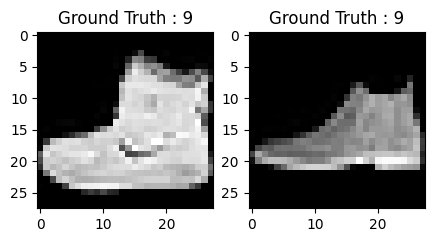

In [30]:
plt.figure(figsize=[5,5])
# Display the first image in training data as a data matrix
plt.subplot(121)
plt.imshow(X_train[0,:,:], cmap='gray') # printing 10th image
plt.title("Ground Truth : {}".format(y_train[0])) #title

# Display the first image in testing data
plt.subplot(122)
plt.imshow(X_test[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(y_test[0]))

In [31]:
# Normalize data
# Pixel value of the image falls between 0 to 255.
X_train = X_train / 255.0 # So, we are scale the value between 0 to 1 before by deviding each value by 255
X_test = X_test / 255.0  # So, we are scale the value between 0 to 1 before by deviding each value by 255
# Reshape to add channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [32]:
import tensorflow as tf
from tensorflow.keras import layers

# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel images with a single color channel

# CNN model building

model = tf.keras.Sequential([
    input_layer, # input layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    # filter is the number of filters we want to apply
    # kernel is the size of window/filter moving over the image
    layers.Conv2D(filters=10, kernel_size=(3, 3),  activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer

    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer

    layers.Flatten(), # flatten layer
    layers.Dense(10, activation='softmax') # output layer 
])

In [33]:
#view the CNN model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape               ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                   │ (None, 26, 26, 10)         │             100 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                   │ (None, 24, 24, 10)         │             910 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)      │ (None, 12, 12, 10)         │               0 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                   │ (None, 10, 10, 10)         │             910 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                   │ (None, 8, 8, 10)           │             910 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)      │ (None, 4, 4, 10)           │               0 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                 │ (None, 160)                │               0 │
├─────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                     │ (None, 10)                 │           1,610 │
└─────────────────────────────────────┴────────────────────────────┴─────────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile the model
# if we use softmax activation in output layer then best fit optimizer is categorical_crossentropy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
# Train the model
model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=64)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8411 - loss: 0.4415 - val_accuracy: 0.8507 - val_loss: 0.4159
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8586 - loss: 0.3986 - val_accuracy: 0.8522 - val_loss: 0.4122
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8669 - loss: 0.3759 - val_accuracy: 0.8569 - val_loss: 0.3896
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8711 - loss: 0.3614 - val_accuracy: 0.8664 - val_loss: 0.3750
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8744 - loss: 0.3516 - val_accuracy: 0.8702 - val_loss: 0.3635
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8776 - loss: 0.3432 - val_accuracy: 0.8687 - val_loss: 0.3654
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8790 - loss: 0.3336 - val_accuracy: 0.8765 - val_loss: 0.3447
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8814 - loss: 0.3275 - val_accuracy: 0

In [50]:
# evaluate accuracy of the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3484
Test Accuracy: 87.87%


In [51]:
# Defining array. Each item of array represent integer value of labels. 10 clothing item for 10 integer label.

class_names =['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [52]:
# predicting case 1 for test_images

predictions=model.predict(X_test)

# Prediction of the 1st result. It will show the 10 predictions of labels for test image
print("1. Prediction array: %s" % (predictions[0]))

# we will verify that which result for label has highest confidence
print("2. Label number having highest confidence in prediction array: %s" % (np.argmax(predictions[0])))

# let us verify what is the label in test_labels.
print("3. Actual label in dataset: %s" % (y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1. Prediction array: [2.6014044e-08 3.7419858e-09 4.8418823e-08 5.4652023e-08 6.8491090e-08
 3.5530413e-03 5.5437329e-08 3.4382243e-02 1.9510953e-04 9.6186936e-01]
2. Label number having highest confidence in prediction array: 9
3. Actual label in dataset: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
#Observation
#This means model shows most confidence about 1st test_image is 'Ankle boot' ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])
#test_labels[0] also gives result as 9 (i.e. 'Ankle boot'). So, the prediction is correct. The data is one hot encoded so there is 1 at the last

In [49]:
#Prediction case 2 for test_images
predicted_classes = model.predict(X_test) #Produces probability distribution for each image
predicted_classes = np.argmax(predicted_classes, axis=1) #Converts probabilities into class indices
class_names[predicted_classes[0]] #convert to actual clothing name

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


'Ankle boot'

In [47]:
test_img = X_test[0] #Get the first test image
prediction = model.predict(X_test) #Get predictions for ALL test images
prediction[0] #Get prediction probabilities for the first image

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([2.6014044e-08, 3.7419858e-09, 4.8418823e-08, 5.4652023e-08,
       6.8491090e-08, 3.5530413e-03, 5.5437329e-08, 3.4382243e-02,
       1.9510953e-04, 9.6186936e-01], dtype=float32)

In [48]:
np.argmax(prediction[0])

np.int64(9)

In [ ]:
#observations
#Class 9 has the highest confidence.
#The model predicts this image as “Ankle boot”